# Transit Selection — Per Planet
**Goal:** Manually confirm individual transits per planet until 30 clean transits are selected.

**Workflow per planet:**
1. Set `PLANET` below — sector auto-loads from `sector_selection.csv`
2. Run all cells → see full sector overview + zoomed view of every transit
3. Edit `ACCEPTED` in the selection cell to keep/reject individual transits
4. If count < 30, add more sectors to `EXTRA_SECTORS`
5. Run the save cell → appends to `results/N30/transit_selection.csv`

In [1]:
# ── Copy-paste reference for Cell below (PLANET + EXTRA_SECTORS) ─────────────
# Each line shows: planet name, primary sector, then all backup sectors sorted by usable count.
# To work on a planet: copy its PLANET line and EXTRA_SECTORS line into the next cell.
#
# Format: S{sector}({n_usable transits in that sector})

import os, pandas as pd
from IPython.display import display, HTML

BASE_DIR    = os.getcwd()
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
N30_DIR     = os.path.join(RESULTS_DIR, 'N30')

sel_df  = pd.read_csv(os.path.join(N30_DIR, 'sector_selection.csv'))
tsel_path = os.path.join(N30_DIR, 'transit_selection.csv')
tsel_counts = {}
if os.path.exists(tsel_path):
    tsel_counts = pd.read_csv(tsel_path).groupby('planet').size().to_dict()

lines = []
for _, row in sel_df.iterrows():
    planet     = row['planet']
    primary    = int(row['sector'])
    n_saved    = tsel_counts.get(planet, 0)
    status     = '✓' if n_saved >= 30 else ('…' if n_saved > 0 else ' ')

    rep_path = os.path.join(RESULTS_DIR, 'survey', planet, 'sector_report.csv')
    backups  = []
    if os.path.exists(rep_path):
        rep = pd.read_csv(rep_path)
        rep = rep[rep['sector'] != 'Total']
        rep['sector'] = rep['sector'].astype(int)
        rep = rep[(rep['n_usable'] > 0) & (rep['sector'] != primary)]
        rep = rep.sort_values('n_usable', ascending=False)
        backups = [int(r['sector']) for _, r in rep.iterrows()]

    backup_str = f'[{", ".join(str(s) for s in backups)}]' if backups else '[]'
    lines.append(
        f'[{status}] {planet:<22}  '
        f'PLANET = \'{planet}\'   '
        f'# primary S{primary} ({n_saved} saved)   '
        f'EXTRA_SECTORS = {backup_str}'
    )

print('─' * 90)
print('  STATUS  PLANET                  COPY-PASTE READY')
print('─' * 90)
for line in lines:
    print(line)
print('─' * 90)
print('✓ = 30+ saved   … = in progress   (blank) = not started')
print()
print('Backup sectors listed in order of most usable transits first.')

──────────────────────────────────────────────────────────────────────────────────────────
  STATUS  PLANET                  COPY-PASTE READY
──────────────────────────────────────────────────────────────────────────────────────────
[ ] TOI-157                 PLANET = 'TOI-157'   # primary S11 (0 saved)   EXTRA_SECTORS = [98, 89, 64, 39, 13, 33, 38, 30, 32, 94, 34, 90, 31, 9, 12, 37, 27, 29, 95, 93, 36, 62, 35, 63, 65, 68, 96, 28, 61, 69, 88, 87, 66, 67]
[ ] WASP-019                PLANET = 'WASP-019'   # primary S63 (0 saved)   EXTRA_SECTORS = [89, 90, 62, 9, 36, 99]
[ ] TOI-1259                PLANET = 'TOI-1259'   # primary S58 (0 saved)   EXTRA_SECTORS = [20, 41, 75, 51, 40, 26, 19, 53, 55, 52, 79, 21, 25, 18, 24, 14, 80, 59, 47, 54, 78, 48, 50, 86, 73, 60, 77, 85, 17, 74, 81]
[ ] HIP_00065               PLANET = 'HIP_00065'   # primary S28 (0 saved)   EXTRA_SECTORS = [1, 2, 96, 102, 95, 29, 68, 69]
[ ] KELT-23                 PLANET = 'KELT-23'   # primary S14 (0 saved)   EXTRA_S

In [2]:
# ── Master progress board — run this cell anytime to see current status ──────
import os, pandas as pd
from IPython.display import display, HTML

BASE_DIR    = os.getcwd()
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
N30_DIR     = os.path.join(RESULTS_DIR, 'N30')
DATA_DIR    = os.path.join(BASE_DIR, 'data')

# Load confirmed sector selections
sel_path = os.path.join(N30_DIR, 'sector_selection.csv')
sel_df   = pd.read_csv(sel_path) if os.path.exists(sel_path) else pd.DataFrame()

# Load transit selections (how many transits saved so far)
tsel_path = os.path.join(N30_DIR, 'transit_selection.csv')
tsel_df   = pd.read_csv(tsel_path) if os.path.exists(tsel_path) else pd.DataFrame()
tsel_counts = tsel_df.groupby('planet').size().to_dict() if not tsel_df.empty else {}

# Load all available sectors per planet from sector_report
pri = pd.read_csv(os.path.join(DATA_DIR, 'planets_priority.csv'))

rows = []
for _, row in sel_df.iterrows():
    planet = row['planet']
    primary_sec = int(row['sector'])

    # All sectors with usable transits
    rep_path = os.path.join(RESULTS_DIR, 'survey', planet, 'sector_report.csv')
    all_secs = []
    if os.path.exists(rep_path):
        rep = pd.read_csv(rep_path)
        rep = rep[rep['sector'] != 'Total']
        rep['sector'] = rep['sector'].astype(int)
        rep = rep[rep['n_usable'] > 0].sort_values('n_usable', ascending=False)
        all_secs = [f"S{int(r['sector'])}({int(r['n_usable'])})" for _, r in rep.iterrows()]

    n_saved  = tsel_counts.get(planet, 0)
    status   = '✓ done' if n_saved >= 30 else ('▶ in progress' if n_saved > 0 else '○ not started')
    rows.append(dict(
        planet       = planet,
        primary_sec  = f'S{primary_sec}',
        score        = row.get('score', ''),
        n_saved      = n_saved,
        status       = status,
        all_sectors  = '  '.join(all_secs),
    ))

board = pd.DataFrame(rows)

def color_row(row):
    if row['status'] == '✓ done':
        return ['background-color:#d4edda'] * len(row)
    elif row['status'] == '▶ in progress':
        return ['background-color:#fff3cd'] * len(row)
    else:
        return [''] * len(row)

done  = (board['status'] == '✓ done').sum()
total = len(board)
display(HTML(f'<h3>N30 Transit Selection Progress — {done}/{total} planets complete</h3>'))
display(board.style
        .apply(color_row, axis=1)
        .hide(axis='index')
        .format({'score': '{:.3f}', 'n_saved': '{:d}'})
        .set_properties(**{'font-size': '11px'}))

planet,primary_sec,score,n_saved,status,all_sectors
TOI-157,S11,0.843,0,○ not started,S98(14) S89(13) S13(12) S64(12) S39(12) S32(12) S33(12) S38(12) S30(12) S31(11) S94(11) S34(11) S90(11) S9(10) S11(10) S12(10) S37(10) S27(10) S29(10) S95(10) S93(10) S36(10) S62(10) S35(10) S63(10) S65(10) S68(10) S96(10) S28(9) S61(9) S69(9) S88(9) S87(8) S66(8) S67(8)
WASP-019,S63,0.987,0,○ not started,S89(34) S63(33) S90(32) S9(27) S62(27) S36(26) S99(24)
TOI-1259,S58,0.808,0,○ not started,S20(8) S41(8) S75(8) S21(7) S52(7) S40(7) S26(7) S19(7) S55(7) S58(7) S53(7) S79(7) S51(7) S14(6) S18(6) S25(6) S24(6) S80(6) S59(6) S47(6) S54(6) S78(5) S50(5) S48(5) S86(5) S73(5) S60(5) S77(5) S85(5) S17(4) S74(4) S81(4)
HIP_00065,S28,0.700,0,○ not started,S1(26) S2(26) S102(22) S96(22) S95(21) S29(20) S68(19) S69(19) S28(17)
KELT-23,S14,0.811,0,○ not started,S41(12) S21(11) S47(11) S57(11) S84(10) S14(10) S81(10) S54(10) S48(10) S23(9) S16(8) S74(8) S76(8) S17(8) S49(8) S15(7) S75(7) S50(6) S77(6)
KELT-09,S41,0.968,0,○ not started,S75(19) S41(17) S55(17) S82(17) S15(12) S14(12)
XO-7,S40,0.849,0,○ not started,S40(10) S25(9) S79(9) S26(8) S47(8) S52(8) S53(8) S59(7) S60(7) S73(6) S74(5) S86(5)
TOI-1431,S57,0.889,0,○ not started,S56(11) S15(10) S55(10) S57(10) S76(9) S84(9) S83(9) S16(8) S77(6)
TOI-1518,S58,0.917,0,○ not started,S58(14) S57(13) S85(12) S84(11) S77(9)
KELT-20,S40,0.921,0,○ not started,S40(8) S41(8) S74(8) S75(7) S54(7) S81(6) S14(4)


In [8]:
# ── EDIT THIS CELL: set your target planet ──────────────────────────────────
PLANET = 'WASP-019'

# Additional sectors to include beyond the primary (to reach 30 transits).
# Leave empty on first run — add sector numbers here if primary sector alone
# doesn't provide enough transits.
# Example: EXTRA_SECTORS = [40, 14]
EXTRA_SECTORS = [89, 90]
# ────────────────────────────────────────────────────────────────────────────

In [9]:
import os, re, time as time_mod, warnings
warnings.filterwarnings('ignore')

import lightkurve as lk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from IPython.display import display, Image, HTML

BASE_DIR    = os.getcwd()
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
N30_DIR     = os.path.join(RESULTS_DIR, 'N30')
SEL_CSV     = os.path.join(N30_DIR, 'transit_selection.csv')
os.makedirs(N30_DIR, exist_ok=True)

# Load confirmed sector for this planet
sel_path = os.path.join(N30_DIR, 'sector_selection.csv')
sel_df   = pd.read_csv(sel_path)
psel     = sel_df[sel_df['planet'] == PLANET]
if psel.empty:
    raise ValueError(f'{PLANET} not found in sector_selection.csv — confirm it first in inspect_n30.ipynb')

PRIMARY_SECTOR = int(psel.iloc[0]['sector'])
ALL_SECTORS    = [PRIMARY_SECTOR] + [int(s) for s in EXTRA_SECTORS]
print(f'Planet       : {PLANET}')
print(f'Primary sector: S{PRIMARY_SECTOR}')
print(f'All sectors   : {ALL_SECTORS}')

Planet       : WASP-019
Primary sector: S63
All sectors   : [63, 89, 90]


In [10]:
# ── Helper functions ────────────────────────────────────────────────────────
def robust_normalize(lc):
    f = np.array(lc.flux)
    if hasattr(f.flat[0], 'value'):
        f = np.array([v.value for v in f])
    div = np.nanpercentile(f, 75)
    return lk.LightCurve(time=lc.time, flux=f / (div if div else 1.0))

def download_lc(host, sector, retries=3):
    for attempt in range(retries):
        try:
            sr = lk.search_lightcurve(host, mission='TESS', sector=sector,
                                      author='SPOC', exptime=120)
            if not sr or len(sr) == 0: return None
            lc = sr[0].download(flux_column='pdcsap_flux')
            return robust_normalize(lc.remove_nans()) if lc else None
        except Exception:
            if attempt < retries - 1: time_mod.sleep(10)
    return None

def refine_t0(time, flux, t0_init, period, half_dur, n_bins=40):
    phase = (time - t0_init) % period
    phase[phase > period / 2] -= period
    mask = np.abs(phase) <= 2 * half_dur
    if mask.sum() < 20: return t0_init
    p_in, f_in = phase[mask], flux[mask]
    bins = np.linspace(-2*half_dur, 2*half_dur, n_bins+1)
    bct  = 0.5*(bins[:-1]+bins[1:])
    bt, bf = [], []
    for i in range(n_bins):
        sel = (p_in >= bins[i]) & (p_in < bins[i+1])
        if sel.sum() > 0:
            bt.append(bct[i]); bf.append(np.median(f_in[sel]))
    if len(bt) < 5: return t0_init
    bt, bf = np.array(bt), np.array(bf)
    inner = np.abs(bt) <= half_dur
    if inner.sum() < 3: inner = np.ones(len(bt), bool)
    try:
        a, b, _ = np.polyfit(bt[inner], bf[inner], 2)
        if a <= 0: return t0_init
        off = -b / (2*a)
        return t0_init + off if abs(off) <= half_dur else t0_init
    except Exception:
        return t0_init

def get_tcs(tarr, t0, period):
    n_lo = int(np.ceil((tarr.min()  - t0) / period))
    n_hi = int(np.floor((tarr.max() - t0) / period))
    return [t0 + n*period for n in range(n_lo, n_hi+1)
            if tarr.min() <= t0 + n*period <= tarr.max()]

print('Helpers loaded.')

Helpers loaded.


In [ ]:
# ── Load planet parameters + download LCs ───────────────────────────────────
pri  = pd.read_csv(os.path.join(DATA_DIR, 'planets_priority.csv'))
prow = pri[pri['System'] == PLANET].iloc[0]
host   = re.sub(r'\s+[A-D]$', '', str(prow.get('host_star', PLANET))).strip()
period = float(prow['Period'])
T_days = float(prow['pl_trandur']) / 24.0
half_T = T_days / 2.0
depth  = float(prow['pl_trandep']) if pd.notna(prow.get('pl_trandep')) else None

# Load refined t0 from rank cache if available
cache_path = os.path.join(N30_DIR, '_rank_cache.csv')
rank_cache = pd.read_csv(cache_path) if os.path.exists(cache_path) else pd.DataFrame()

def get_t0_init(planet, sec):
    """Get best available starting t0 for a sector."""
    if not rank_cache.empty:
        rc = rank_cache[(rank_cache['planet'] == planet) & (rank_cache['sector'] == sec)]
        if not rc.empty:
            if 't0_refined_btjd' in rc.columns:
                return float(rc.iloc[0]['t0_refined_btjd'])
            if 't0_lit_btjd' in rc.columns:
                return float(rc.iloc[0]['t0_lit_btjd'])
    rep_path = os.path.join(RESULTS_DIR, 'survey', planet, 'sector_report.csv')
    if os.path.exists(rep_path):
        rep = pd.read_csv(rep_path)
        rep = rep[rep['sector'] != 'Total']
        rep['sector'] = rep['sector'].astype(int)
        rr  = rep[rep['sector'] == sec]
        if not rr.empty:
            return float(rr.iloc[0]['t0_sec_btjd'])
    return None

def propagate_t0(t0_ref, period, tarr):
    """Shift t0_ref by N periods to land near the middle of tarr."""
    t_mid = (tarr.min() + tarr.max()) / 2
    n     = round((t_mid - t0_ref) / period)
    return t0_ref + n * period

sector_data  = {}
t0_primary   = None   # refined t0 from PRIMARY sector — used to seed extra sectors

for sec in ALL_SECTORS:
    is_primary = (sec == PRIMARY_SECTOR)

    print(f'S{sec} {"(primary)" if is_primary else "(extra)  "} — downloading...', end=' ', flush=True)
    lc = download_lc(host, sec)
    if lc is None:
        print('FAILED'); continue

    tarr = np.array(lc.time.value) if hasattr(lc.time, 'value') else np.array(lc.time)
    farr = np.array(lc.flux.value) if hasattr(lc.flux, 'value') else np.array(lc.flux)

    if is_primary or t0_primary is None:
        # Primary sector: use cache/sector_report as starting point
        t0_init = get_t0_init(PLANET, sec)
    else:
        # Extra sector: propagate primary's refined t0 to this sector's time range
        t0_init = propagate_t0(t0_primary, period, tarr)

    if t0_init is None:
        t0_init = tarr.min()

    # Stack-refine from the (now well-seeded) starting point
    t0 = refine_t0(tarr, farr, t0_init, period, half_T)

    # Report shift from seed
    shift_min = (t0 - t0_init) * 24 * 60
    tcs = get_tcs(tarr, t0, period)
    sector_data[sec] = dict(tarr=tarr, farr=farr, t0=t0, tcs=tcs)

    if is_primary:
        t0_primary = t0   # save for extra sectors

    print(f'{len(tarr)} pts  |  {len(tcs)} transits  |  t0 shift={shift_min:+.1f} min from seed')

total_transits = sum(len(v['tcs']) for v in sector_data.values())
print(f'\nTotal transits available across {len(sector_data)} sector(s): {total_transits}')
if t0_primary is not None:
    print(f'Primary t0 used as seed for extra sectors: {t0_primary:.6f} BTJD')

In [ ]:
# ── Interactive offset sliders — one per sector ──────────────────────────────
# Drag the slider for a sector to shift its transit windows left/right.
# When satisfied, click "Apply & Print Offsets" to lock in the values and
# print the SECTOR_OFFSETS dict you can paste into the cell below if needed.
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Build one FloatSlider per sector
sliders = {}
for sec in sector_data:
    sliders[sec] = widgets.FloatSlider(
        value=0.0, min=-120.0, max=120.0, step=0.5,
        description=f'S{sec} (min)',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='500px'),
        continuous_update=False,   # only redraw on mouse release (faster)
        readout_format='.1f',
    )

plot_out = widgets.Output()

def redraw(_=None):
    with plot_out:
        clear_output(wait=True)
        for sec, sd in sector_data.items():
            tarr, farr = sd['tarr'], sd['farr']
            offset_days = sliders[sec].value / 60 / 24
            tcs = [tc + offset_days for tc in sd['tcs']]
            noise = np.std(farr) * 1e6

            fig, ax = plt.subplots(figsize=(22, 3.5))
            ax.scatter(tarr, farr, s=0.8, color='#333', zorder=2, rasterized=True)
            legend_done = set()
            for i, tc in enumerate(tcs):
                ax.axvspan(tc-1.5*T_days, tc-half_T,     color='#cce5ff', alpha=0.45, zorder=1,
                           label='Pre'     if 'pre' not in legend_done else '_')
                ax.axvspan(tc-half_T,     tc+half_T,     color='#ffcccc', alpha=0.55, zorder=1,
                           label='Transit' if 'tr'  not in legend_done else '_')
                ax.axvspan(tc+half_T,     tc+1.5*T_days, color='#ccffdd', alpha=0.45, zorder=1,
                           label='Post'    if 'post' not in legend_done else '_')
                ax.axvline(tc, color='red', lw=0.8, alpha=0.7, zorder=3)
                ax.text(tc, farr.max()+0.0004, str(i+1),
                        color='red', fontsize=7, ha='center', fontweight='bold')
                legend_done.update({'pre','tr','post'})
            ax.set_xlim(tarr.min(), tarr.max())
            ax.set_xlabel('BTJD', fontsize=9)
            ax.set_ylabel('Norm. flux', fontsize=9)
            off_str = f'  offset={sliders[sec].value:+.1f} min' if sliders[sec].value != 0 else ''
            title = f'{PLANET}  |  Sector {sec}{off_str}  |  σ={noise:.0f} ppm'
            if depth: title += f'   depth={depth:.0f} ppm   SNR~{depth/noise:.1f}'
            title += f'   T={T_days*24:.2f}h   {len(tcs)} transits'
            ax.set_title(title, fontsize=10, fontweight='bold')
            patches = [mpatches.Patch(color='#cce5ff', alpha=0.7, label='Pre-baseline'),
                       mpatches.Patch(color='#ffcccc', alpha=0.7, label='Transit'),
                       mpatches.Patch(color='#ccffdd', alpha=0.7, label='Post-baseline')]
            ax.legend(handles=patches, fontsize=8, loc='upper right')
            ax.spines[['top','right']].set_visible(False)
            plt.tight_layout()
            plt.show()

apply_btn = widgets.Button(description='Apply & Print Offsets',
                           button_style='success',
                           layout=widgets.Layout(width='200px'))

def apply_offsets(_):
    for sec, sl in sliders.items():
        if sl.value != 0:
            offset_days = sl.value / 60 / 24
            sector_data[sec]['tcs'] = [tc + offset_days for tc in sector_data[sec]['tcs']]
    # reset sliders to 0 after applying
    for sl in sliders.values():
        sl.value = 0.0
    # print dict for reference
    nonzero = {sec: sl.value for sec, sl in sliders.items() if sl.value != 0}
    print('Offsets applied to sector_data.')
    print('SECTOR_OFFSETS (for reference):', nonzero if nonzero else '{} (all zero)')
    redraw()

apply_btn.on_click(apply_offsets)

for sl in sliders.values():
    sl.observe(redraw, names='value')

# Initial render
redraw()
display(widgets.VBox(list(sliders.values()) + [apply_btn]))
display(plot_out)

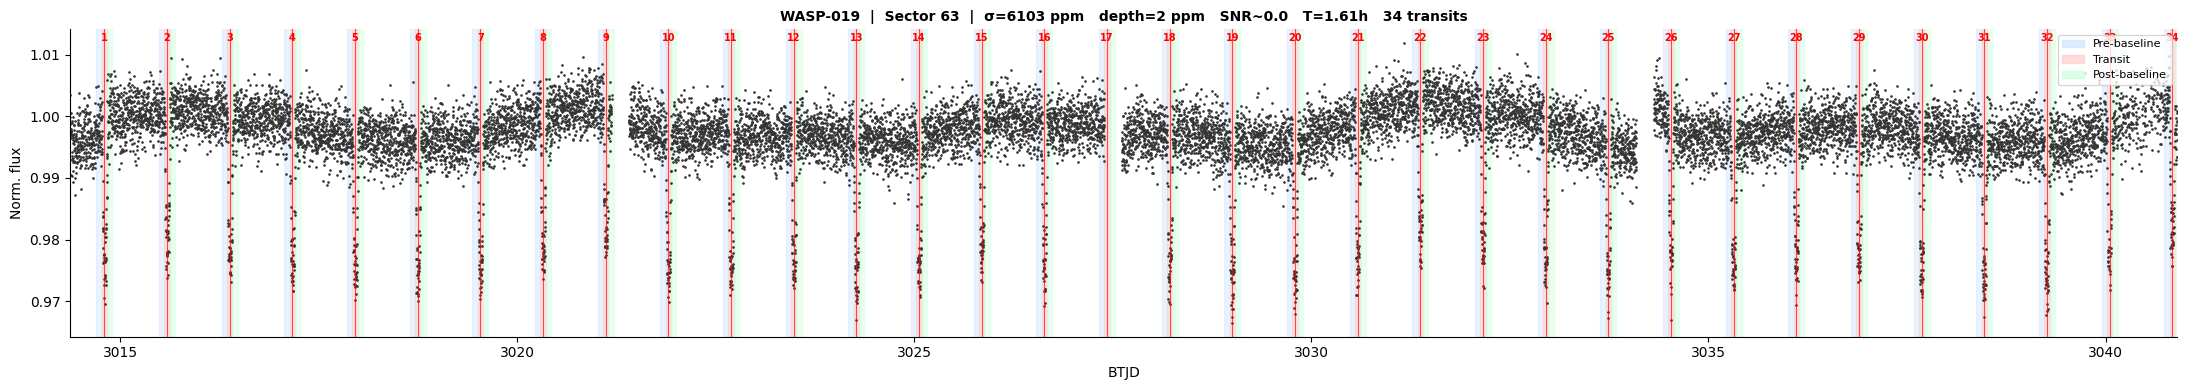

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\WASP-019_S063_overview.png



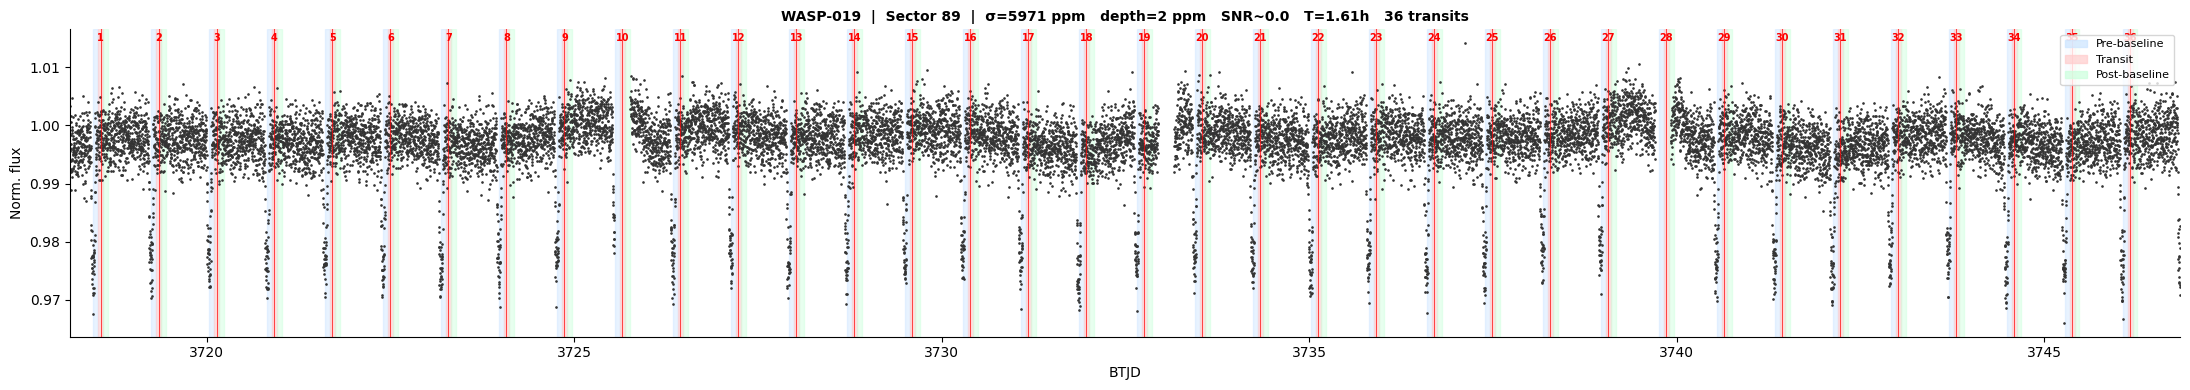

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\WASP-019_S089_overview.png



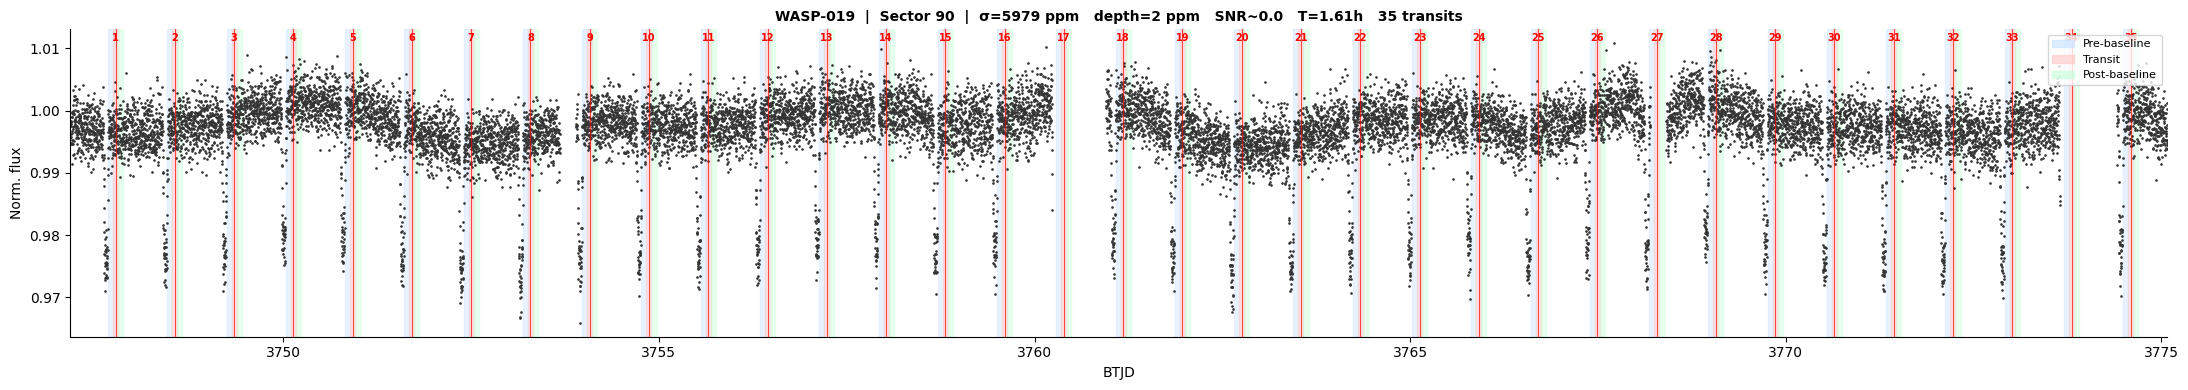

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\WASP-019_S090_overview.png



In [12]:
# ── Plot full sector overview(s) ─────────────────────────────────────────────
for sec, sd in sector_data.items():
    tarr, farr, tcs = sd['tarr'], sd['farr'], sd['tcs']
    noise = np.std(farr) * 1e6

    fig, ax = plt.subplots(figsize=(22, 4))
    ax.scatter(tarr, farr, s=0.8, color='#333', zorder=2, rasterized=True)
    legend_done = set()
    for i, tc in enumerate(tcs):
        ax.axvspan(tc-1.5*T_days, tc-half_T,      color='#cce5ff', alpha=0.45, zorder=1,
                   label='Pre'     if 'pre' not in legend_done else '_')
        ax.axvspan(tc-half_T,     tc+half_T,      color='#ffcccc', alpha=0.55, zorder=1,
                   label='Transit' if 'tr'  not in legend_done else '_')
        ax.axvspan(tc+half_T,     tc+1.5*T_days,  color='#ccffdd', alpha=0.45, zorder=1,
                   label='Post'    if 'post' not in legend_done else '_')
        ax.axvline(tc, color='red', lw=0.8, alpha=0.7, zorder=3)
        ax.text(tc, farr.max()+0.0004, str(i+1),
                color='red', fontsize=7, ha='center', fontweight='bold')
        legend_done.update({'pre','tr','post'})
    ax.set_xlim(tarr.min(), tarr.max())
    ax.set_xlabel('BTJD', fontsize=10)
    ax.set_ylabel('Norm. flux', fontsize=10)
    title = f'{PLANET}  |  Sector {sec}  |  σ={noise:.0f} ppm'
    if depth: title += f'   depth={depth:.0f} ppm   SNR~{depth/noise:.1f}'
    title += f'   T={T_days*24:.2f}h   {len(tcs)} transits'
    ax.set_title(title, fontsize=10, fontweight='bold')
    patches = [mpatches.Patch(color='#cce5ff', alpha=0.7, label='Pre-baseline'),
               mpatches.Patch(color='#ffcccc', alpha=0.7, label='Transit'),
               mpatches.Patch(color='#ccffdd', alpha=0.7, label='Post-baseline')]
    ax.legend(handles=patches, fontsize=8, loc='upper right')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()

    # Save overview to N30
    out = os.path.join(N30_DIR, f'{PLANET}_S{sec:03d}_overview.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}\n')

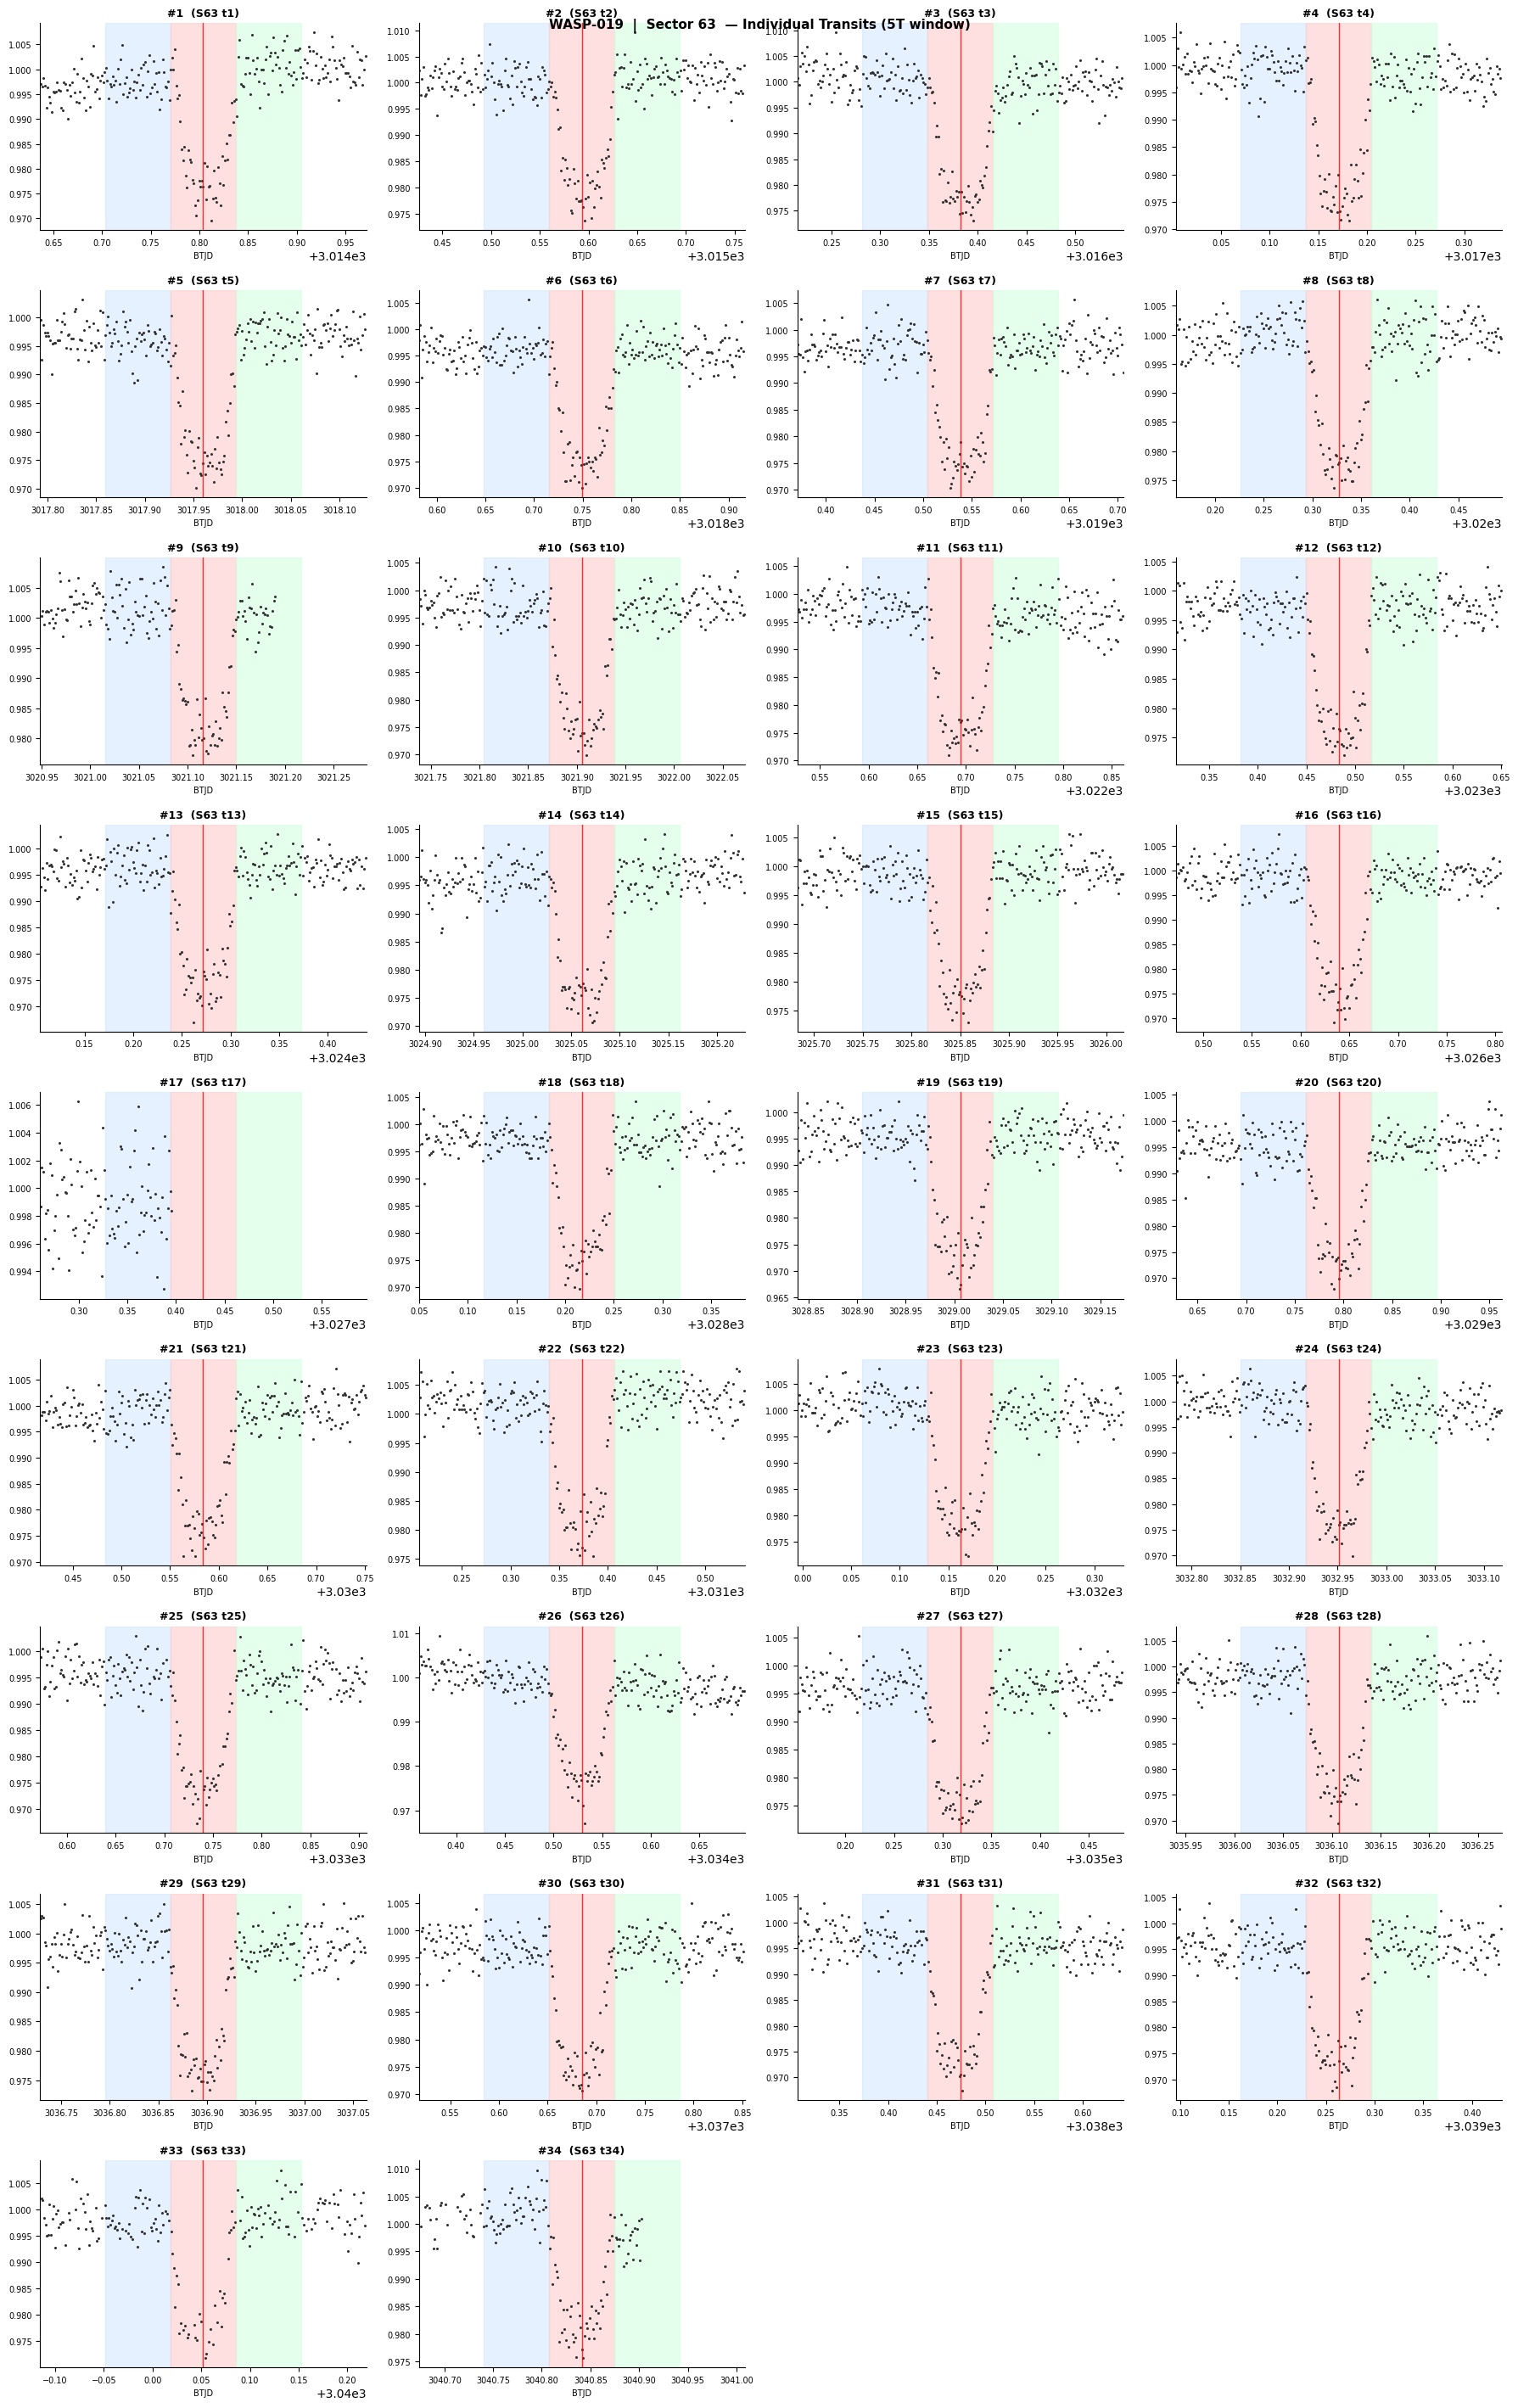

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\WASP-019_S063_transits_zoom.png



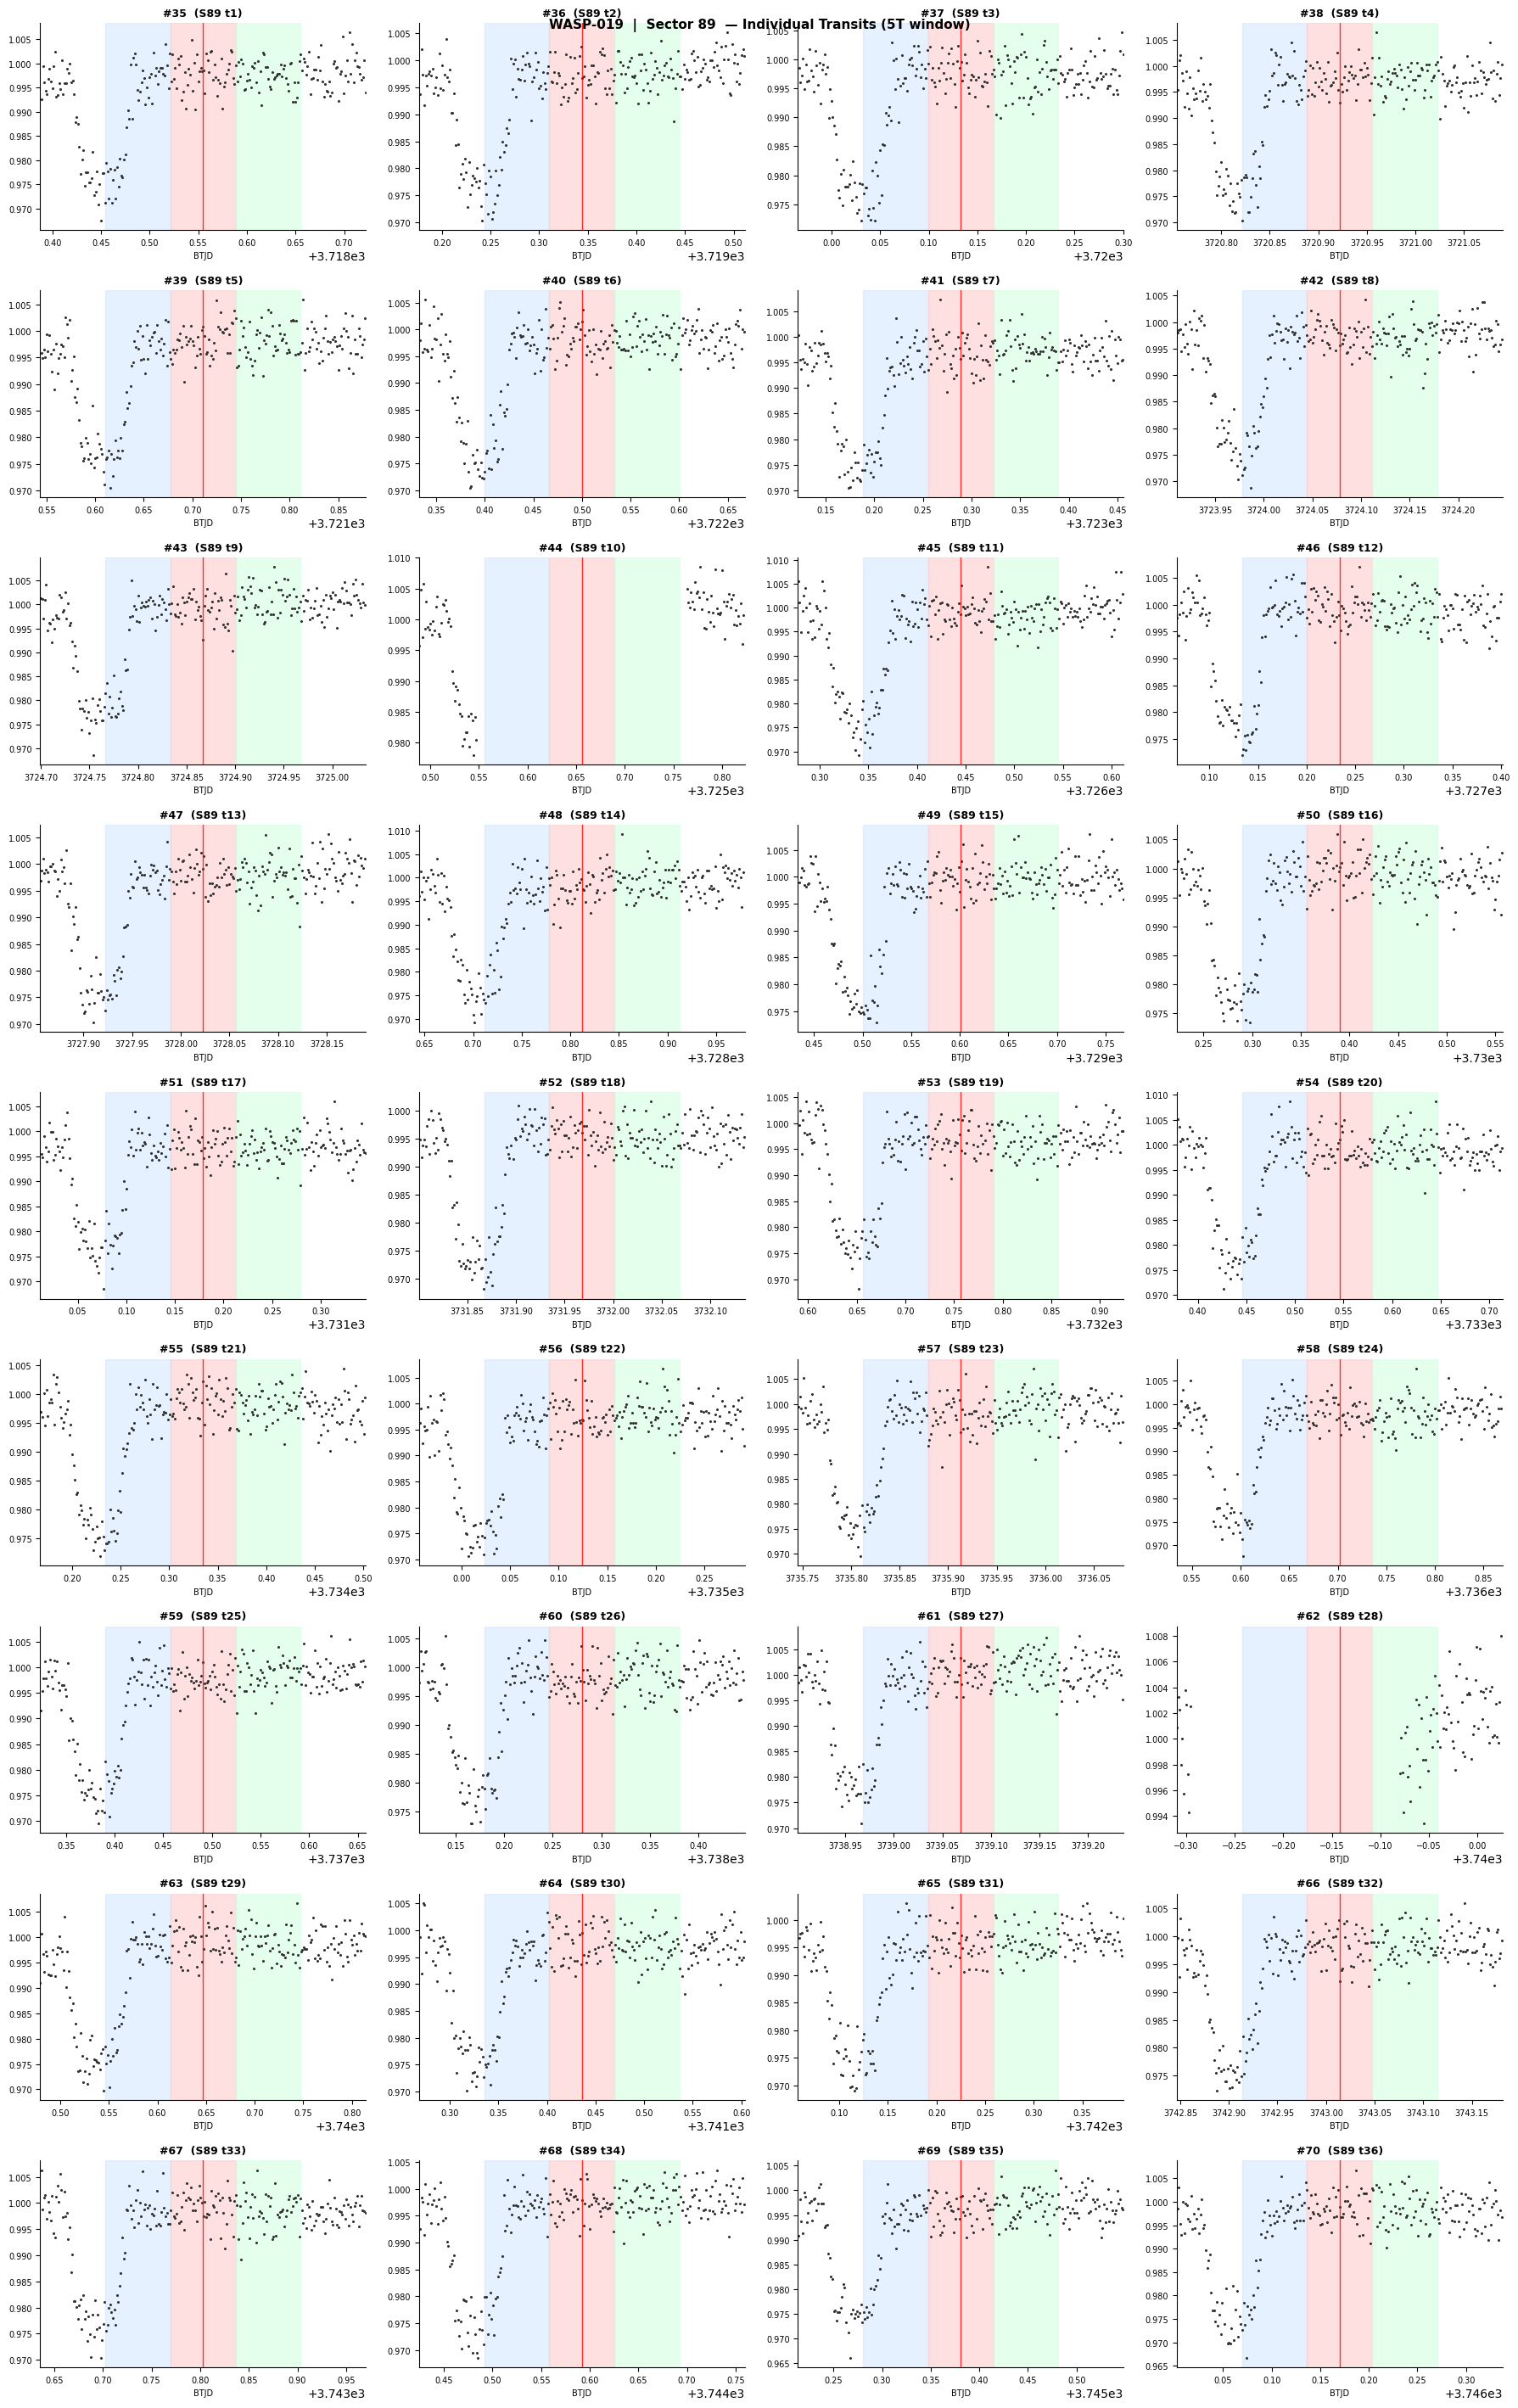

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\WASP-019_S089_transits_zoom.png



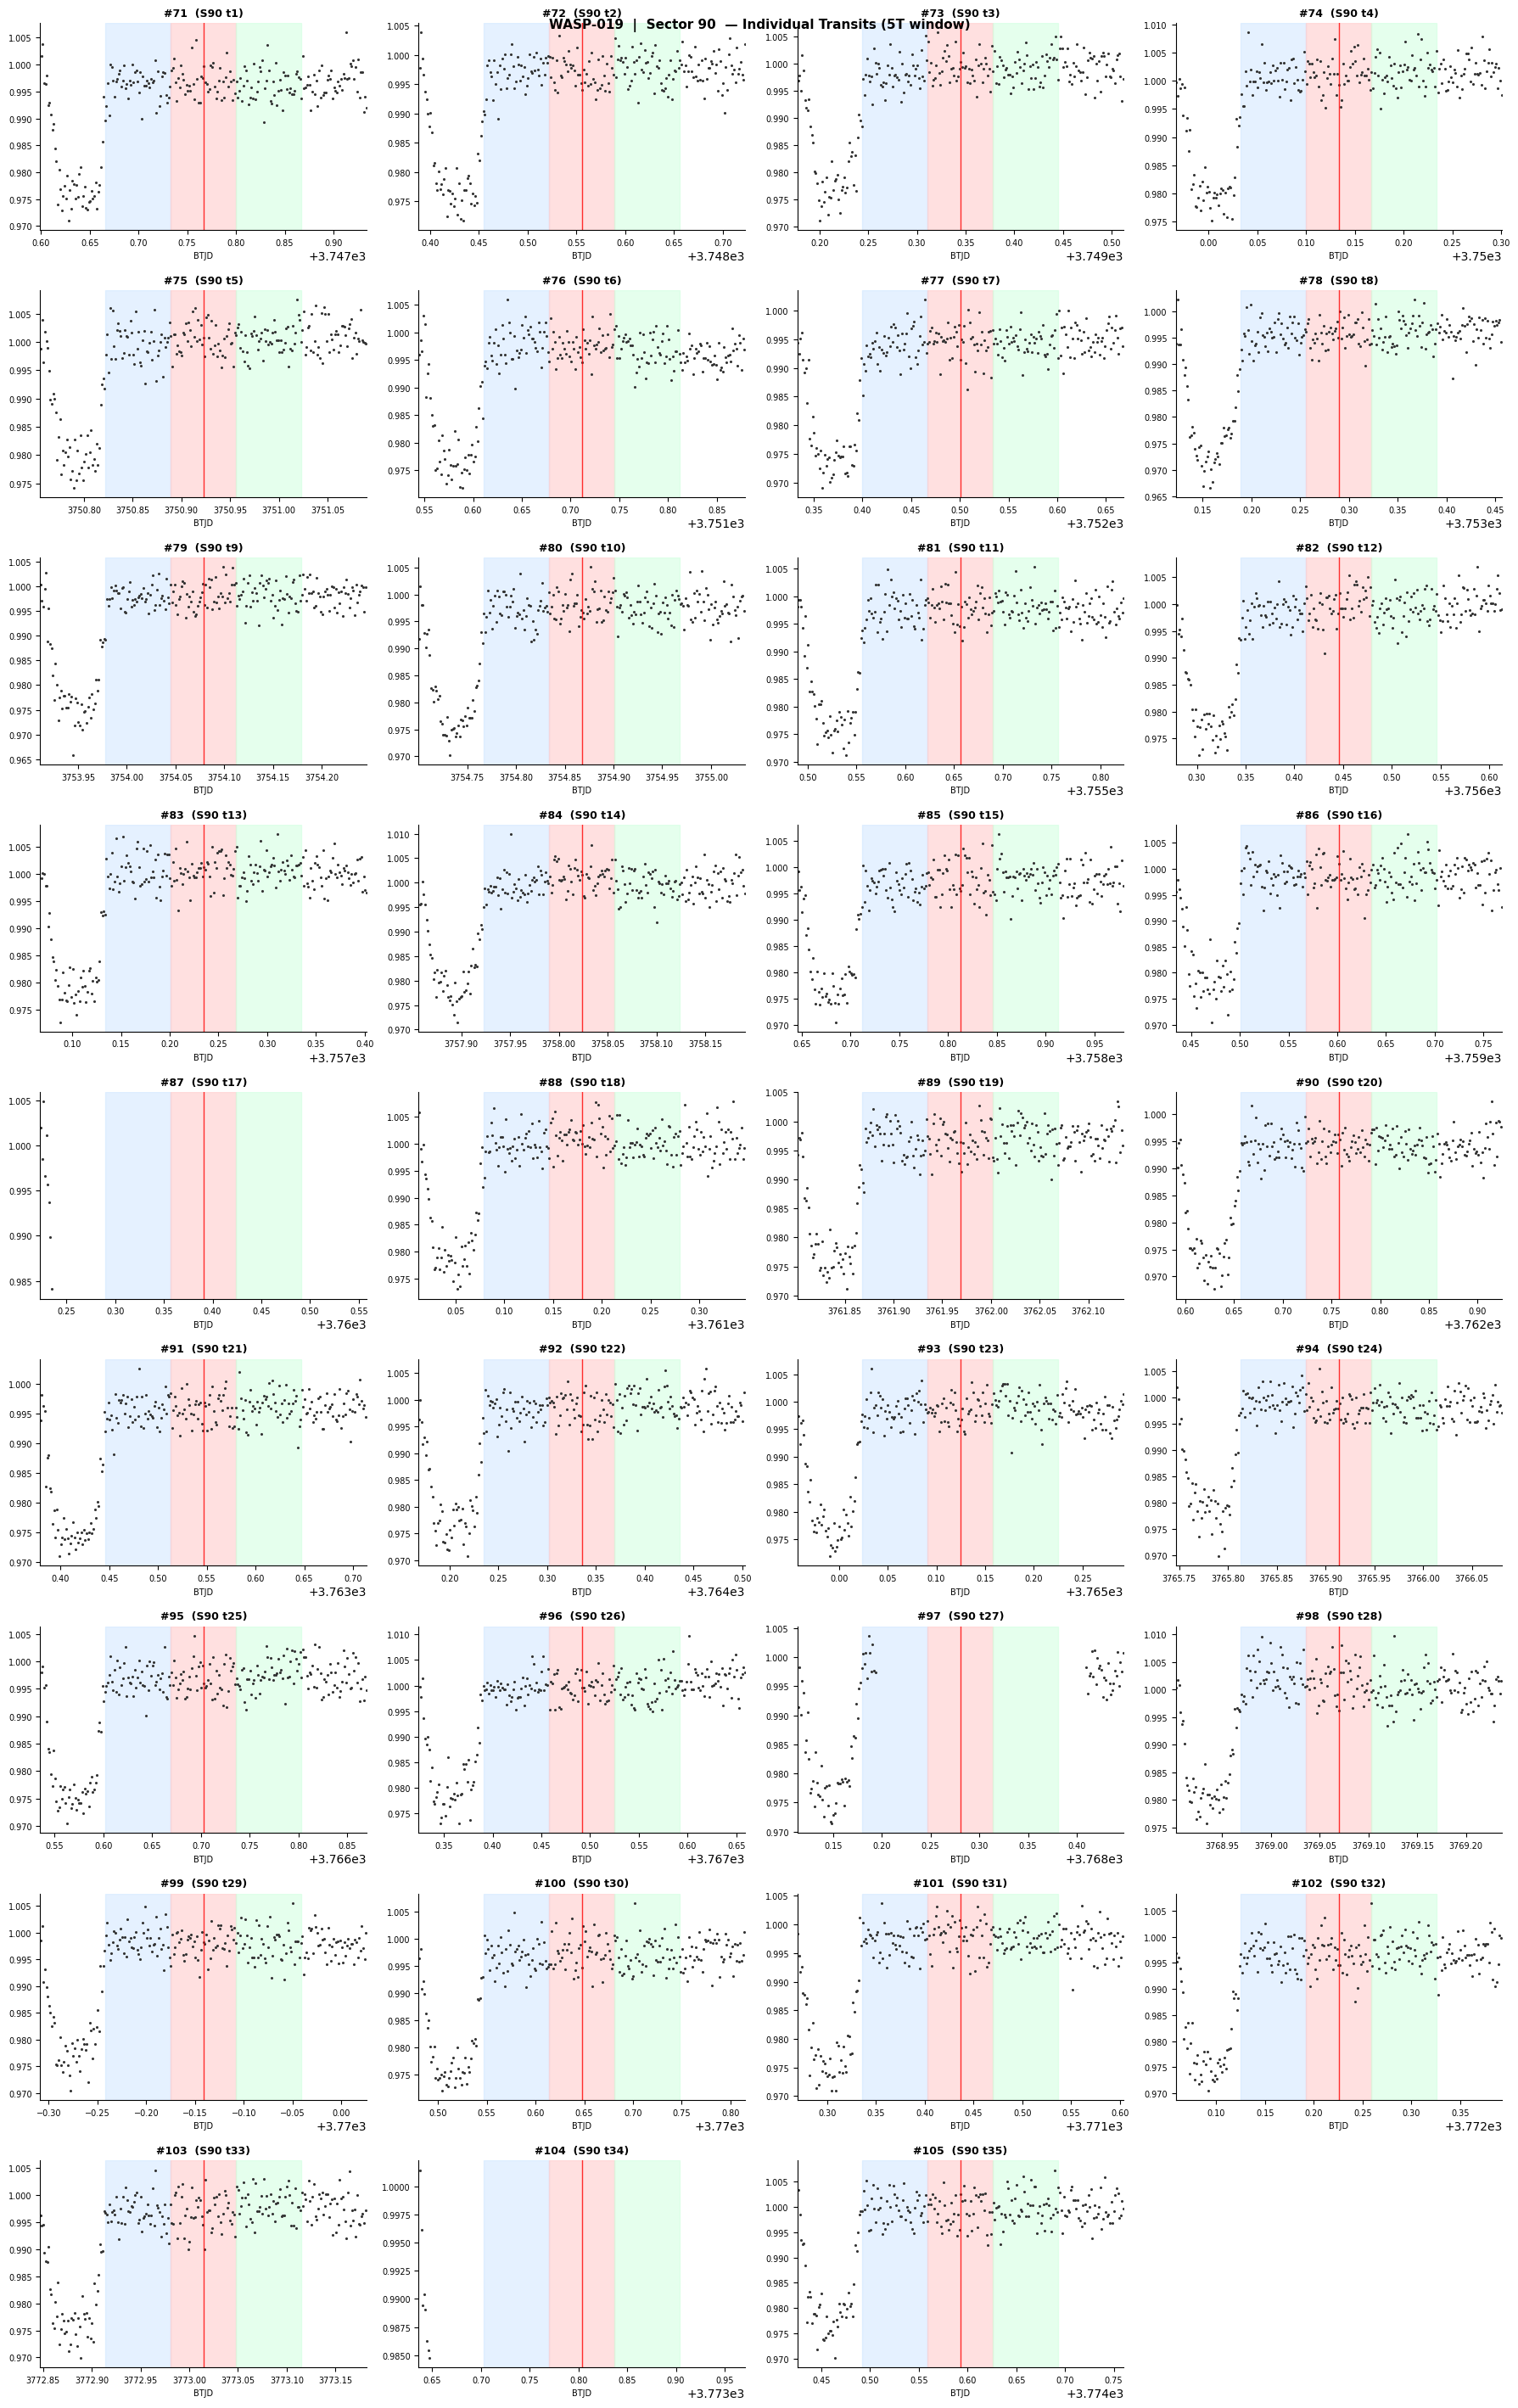

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\WASP-019_S090_transits_zoom.png

Total transits shown: 105
Use the #numbers above in the ACCEPTED cell below.


In [13]:
# ── Zoomed view: every transit individually (5T window) ──────────────────────
# Each transit is numbered. Use these numbers in the ACCEPTED dict below.

transit_index = {}   # global_n → (sector, local_n, tc)
global_n = 1

for sec, sd in sector_data.items():
    tarr, farr, tcs = sd['tarr'], sd['farr'], sd['tcs']
    n_cols = min(4, len(tcs))
    n_rows = int(np.ceil(len(tcs) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols*4.5, n_rows*3.2),
                             squeeze=False)
    fig.suptitle(f'{PLANET}  |  Sector {sec}  — Individual Transits (5T window)',
                 fontsize=11, fontweight='bold')

    for j, tc in enumerate(tcs):
        row, col = divmod(j, n_cols)
        ax = axes[row][col]
        win = 2.5 * T_days
        mask = (tarr >= tc - win) & (tarr <= tc + win)
        t_w, f_w = tarr[mask], farr[mask]

        ax.scatter(t_w, f_w, s=1.5, color='#333', zorder=2)
        ax.axvspan(tc-1.5*T_days, tc-half_T,     color='#cce5ff', alpha=0.5)
        ax.axvspan(tc-half_T,     tc+half_T,     color='#ffcccc', alpha=0.6)
        ax.axvspan(tc+half_T,     tc+1.5*T_days, color='#ccffdd', alpha=0.5)
        ax.axvline(tc, color='red', lw=1.0, alpha=0.8)
        ax.set_xlim(tc - win, tc + win)
        ax.set_title(f'#{global_n}  (S{sec} t{j+1})', fontsize=9, fontweight='bold')
        ax.set_xlabel('BTJD', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.spines[['top','right']].set_visible(False)

        transit_index[global_n] = (sec, j+1, round(tc, 6))
        global_n += 1

    # Hide unused subplots
    for j in range(len(tcs), n_rows*n_cols):
        row, col = divmod(j, n_cols)
        axes[row][col].set_visible(False)

    plt.tight_layout()
    out = os.path.join(N30_DIR, f'{PLANET}_S{sec:03d}_transits_zoom.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}\n')

total_available = global_n - 1
print(f'Total transits shown: {total_available}')
print('Use the #numbers above in the ACCEPTED cell below.')

In [15]:
# ── EDIT THIS CELL: mark which transits to accept ───────────────────────────
# List the #numbers (from the zoomed plots above) that look clean.
# Remove any with: data gaps, strong baseline drift, bad alignment, or partial coverage.
# Target: 30 accepted transits.
# If you don't have enough here, add sector numbers to EXTRA_SECTORS in Cell 1 and re-run.

ACCEPTED = [n for n in range(1, 35) if n not in [9, 34]]    # start with all, remove bad ones

# Example — remove bad transits:
# ACCEPTED = [1,2,3,5,6,7,9,10,11,12,14,15]   # removed 4,8,13
# ────────────────────────────────────────────────────────────────────────────

print(f'Accepted: {len(ACCEPTED)} / {total_available} transits')
if len(ACCEPTED) >= 30:
    display(HTML('<p style="color:green;font-weight:bold;font-size:14px">✓ 30+ transits selected — ready to save.</p>'))
else:
    needed = 30 - len(ACCEPTED)
    display(HTML(f'<p style="color:darkorange;font-weight:bold;font-size:14px">'
                 f'⚠ Need {needed} more transits. Add sectors to EXTRA_SECTORS in Cell 1.</p>'))

Accepted: 32 / 105 transits


In [25]:
# ── Summary table of accepted transits ──────────────────────────────────────
rows = []
for n in ACCEPTED:
    if n not in transit_index:
        print(f'Warning: #{n} not found in transit_index')
        continue
    sec, local_n, tc = transit_index[n]
    rows.append(dict(global_n=n, sector=sec, transit_in_sector=local_n, tc_btjd=tc))

accepted_df = pd.DataFrame(rows)
print(f'{PLANET} — {len(accepted_df)} accepted transits\n')
display(accepted_df)

WASP-019 — 32 accepted transits



,global_n,sector,transit_in_sector,tc_btjd
0,1,63,1,3014.804015
1,2,63,2,3015.593015
2,3,63,3,3016.382015
3,4,63,4,3017.171015
4,5,63,5,3017.960015
5,6,63,6,3018.749015
6,7,63,7,3019.538015
7,8,63,8,3020.327015
8,10,63,10,3021.905015
9,11,63,11,3022.694015


In [26]:
# ── Save to results/N30/transit_selection.csv ────────────────────────────────
# Appends to existing file; replaces any prior entries for this planet.

accepted_df.insert(0, 'planet', PLANET)

if os.path.exists(SEL_CSV):
    existing = pd.read_csv(SEL_CSV)
    existing = existing[existing['planet'] != PLANET]   # remove old entries
    final_df = pd.concat([existing, accepted_df], ignore_index=True)
else:
    final_df = accepted_df

final_df.to_csv(SEL_CSV, index=False)

# Progress summary
n_planets_done = final_df['planet'].nunique()
print(f'Saved: {SEL_CSV}')
print(f'{PLANET}: {len(accepted_df)} transits saved')
print(f'\nOverall progress: {n_planets_done} / 19 planets with transit selections')
summary = final_df.groupby('planet').size().reset_index(name='n_transits')
summary['status'] = summary['n_transits'].apply(
    lambda x: '✓ ready' if x >= 30 else f'⚠ need {30-x} more')
display(summary)

Saved: c:\Users\pnayg\Desktop\cvif-astro-p1\results\N30\transit_selection.csv
WASP-019: 32 transits saved

Overall progress: 1 / 19 planets with transit selections


,planet,n_transits,status
0,WASP-019,32,✓ ready
